# Molecular prediction by class stratum (axis-100-3000)

Head metrics per class stratum (training support, frequency, class set, presence in the held-out images) and a diagnosis of the extension range: does the model predict the molecules of the new m/z range, or does it predict nothing there?

## Introduction

A macro average over all classes mixes classes with thousands of training positives with classes seen a few
times, and on the wide axis classes of the common range with classes that exist only on the extension. The
strata separate these; the extension diagnostics look at the raw predicted probabilities of each class.

### Assumptions

* `test` pixels come from training images and are spatially correlated with training pixels; `heldout_image`
  pixels come from three images never seen during training. Generalization to new images is therefore judged on
  `heldout_image`, generalization to new pixels on `test`.
* Repetitions differ only in initialization and training seed; they share the split. Five repetitions per axis
  are the experimental units for model-level statements; pixels are not independent units.

* The head was trained with the variational PU loss: annotations are positive, missing annotations are unlabelled.
  `annotation_retrieval` therefore treats unlabelled entries as negatives and underestimates precision when
  annotations are incomplete; `operational_pn` removes entries with signal but no annotation.
* Threshold metrics use $\hat Y \ge 0.5$; VPU logits are treated as 0.5-anchored as in the earlier head analyses.
* Evaluations: `train`, `test`, `test_extended`, `test_combined` (test and extension together, the main per-class
  estimate for rare classes) and `heldout_image`.

        * On the narrow axis every class is `common`; the class-set strata and extension diagnostics are informative on
          the wide axis only.
        * `acquired_fraction` is the fraction of evaluated pixels whose input carries at least $10^{-3}$ of its TIC in
          the class's 100 Da window; a class cannot be detected in pixels where its window was not acquired.

### Notation

* $X \in \mathbb{R}_{\ge 0}^{M}$: TIC-normalized input spectrum on the axis ($M$ bins of 0.55 Da);
  $\hat X = \mathrm{Dec}(\mathrm{Enc}(X))$: its reconstruction (TIC-normalized decoder output).
* $Z = \mathrm{Enc}(X) \in \mathbb{R}^{10}$: latent code; $U$: canonicalized code (bottleneck LayerNorm affine
  removed; rows lie on a sphere of radius $\sqrt{10}$ with zero row sum).
* $\hat Y = \sigma(h(Z)) \in [0, 1]^{C}$: head probabilities of the $C$ train-observed molecule classes.
* $P \in \{\mathrm{train}, \mathrm{test}, \mathrm{test\_extended}, \mathrm{heldout\_image}\}$: pixel population;
  $r = 0, \dots, 4$: repetition (independent training seed of the same configuration).
* $W_1(X, \hat X)$: training Masserstein cost, the exact one-dimensional Wasserstein-1 distance between the
  TIC-normalized spectra, in m/z units.
* Window $W = [a, a + 100)$ m/z, aligned to multiples of 100 on every axis.

* Ranking populations: `annotation_retrieval` (every available entry; annotated = positive, everything else
  negative) and `operational_pn` (only evidence positives P and operational negatives N; unlabelled entries with
  signal at the ion's bins, U, are excluded). Evidence rule: peak above 1.19 % of the spectrum maximum within
  +/- 1 bin.
* AP: average precision per class; macro = mean over eligible classes (at least one positive and one negative in
  the evaluated population and training support); micro = one ranking over all eligible entries.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "prediction_class_strata"
AXIS = "axis-100-3000"

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(catalog.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

POPULATIONS = ['train', 'test', 'test_extended', 'heldout_image']
AXIS_LABEL = settings['axes'][AXIS]['label']
MODEL_LABEL = catalog[catalog.axis == AXIS].display_label.iloc[0]
DATASETS = sorted(load_table(settings, 'heldout_image_reconstruction', 'image_metrics', AXIS).dataset_id.unique())
print('Axis label:', AXIS_LABEL, '| held-out images:', DATASETS)

EVALUATIONS = ['train', 'test', 'test_combined', 'heldout_image']
EVALUATION_COLORS = {name: POPULATION_COLORS[name] for name in EVALUATIONS}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'micro_prevalence', 'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1',
                'hamming_loss']


def metric_table(frame, index, columns, column_order):
    """Mean +/- SD over repetitions of every metric of a long table (`metric`, `value`)."""
    long = frame.drop(columns=[name for name in ('axis',) if name in frame.columns]).copy()
    long['metric'] = pd.Categorical(long.metric, categories=[name for name in METRIC_ORDER if name in set(long.metric)], ordered=True)
    grouped = long.groupby([*index, 'metric', columns], observed=True).value
    cells = grouped.mean().map('{:.4f}'.format) + ' +/- ' + grouped.std().map('{:.4f}'.format)
    shown = cells.unstack(columns)
    return shown[[name for name in column_order if name in shown.columns]]


def metric_columns_table(frame, index):
    """Mean +/- SD over repetitions of every metric column of a wide table."""
    columns = [name for name in METRIC_ORDER if name in frame.columns]
    grouped = frame.drop(columns=[name for name in ('axis',) if name in frame.columns]).groupby(index)[columns]
    return grouped.mean().round(4).astype(str) + ' +/- ' + grouped.std().round(4).astype(str)

all_strata = table('strata_metrics')
strata = all_strata[(all_strata.group == 'all') & (all_strata.population == 'annotation_retrieval')]

Analysis: prediction_class_strata | axis: axis-100-3000 | models: 5
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'inference': '0243c1efb93b9c4c'}
Axis label: 100-3000 m/z | held-out images: ['2024-02-20_01h45m20s', '2024-02-20_01h46m58s', '2024-02-20_01h54m41s']


## Producing the tables this notebook reads

### Methodology

#### Implementation

`prediction_class_strata` joins the per-class ranking tables with class metadata and evaluates stored probabilities for the diagnostics.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis prediction_class_strata > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Macro AP by training support

### Methodology

#### Theoretical

The macro AP within a stratum shows how prediction quality depends on the stratifying property.

#### Implementation

`strata_metrics` rows with grouping `train_support`, ranking population `annotation_retrieval`.

#### Figure descriptions

x = stratum, colour = evaluation population, one point per repetition, bar = mean. Tables: eligible classes, then the complete metric set per evaluation population and stratum (mean +/- SD over repetitions).

evaluation,train,test,test_combined,heldout_image
stratum,,,,
1-9,18.0,16.0,18.0,1.0
10-99,74.0,73.0,74.0,1.0
100-999,150.0,150.0,150.0,1.0
1000+,321.0,321.0,321.0,17.0


average_precision micro_average_precision            roc_auc      micro_roc_auc ap_above_prevalence micro_prevalence          precision             recall                 f1  \
evaluation    stratum                                                                                                                                                                                  
heldout_image 1-9      0.0019 +/- 0.0003       0.0019 +/- 0.0003  0.8877 +/- 0.0138  0.8877 +/- 0.0138   0.0015 +/- 0.0003   0.0003 +/- 0.0        0.0 +/- 0.0        0.0 +/- 0.0        0.0 +/- 0.0   
              10-99    0.2497 +/- 0.0378       0.2497 +/- 0.0378   0.8851 +/- 0.018   0.8851 +/- 0.018   0.1762 +/- 0.0378   0.0735 +/- 0.0        0.0 +/- 0.0        0.0 +/- 0.0        0.0 +/- 0.0   
              100-999   0.7539 +/- 0.064        0.7539 +/- 0.064   0.9577 +/- 0.014   0.9577 +/- 0.014    0.6175 +/- 0.064   0.1363 +/- 0.0  0.9526 +/- 0.0773  0.0172 +/- 0.0106  0.0336 +/- 0.0203   
              1000+    0.3833 +/- 0.0178       0.5864 +/- 0.0203   0.694 +/- 0.0147   0.787 +/- 0.0092   0.1342 +/- 0.0178   0.2491 +/- 0.0  0.3678 +/- 0.0513   0.139 +/- 0.0136  0.1482 +/- 0.0177   
test          1-9      0.2345 +/- 0.0514       0.0221 +/- 0.0069  0.9813 +/- 0.0049  0.9857 +/- 0.0031   0.2343 +/- 0.0514   0.0003 +/- 0.0  0.0561 +/- 0.0285   0.225 +/- 0.1135  0.0618 +/- 0.0296   
              10-99     0.2588 +/- 0.025        0.046 +/- 0.0047  0.9917 +/- 0.0005  0.9909 +/- 0.0007    0.2582 +/- 0.025   0.0007 +/- 0.0  0.0237 +/- 0.0096  0.1493 +/- 0.0294  0.0255 +/- 0.0062   
              100-999  0.6228 +/- 0.0093       0.5517 +/- 0.0808  0.9938 +/- 0.0004  0.9945 +/- 0.0007    0.616 +/- 0.0093   0.0068 +/- 0.0  0.3275 +/- 0.0402  0.2135 +/- 0.0311  0.2147 +/- 0.0309   
              1000+    0.8549 +/- 0.0075         0.885 +/- 0.008  0.9877 +/- 0.0004  0.9925 +/- 0.0003   0.7672 +/- 0.0075   0.0877 +/- 0.0    0.83 +/- 0.0068  0.7813 +/- 0.0123   0.7712 +/- 0.013   
test_combined 1-9       0.2231 +/- 0.035       0.0469 +/- 0.0035  0.9692 +/- 0.0023  0.9582 +/- 0.0038    0.2197 +/- 0.035   0.0034 +/- 0.0  0.1106 +/- 0.0279  0.1823 +/- 0.0619  0.0537 +/- 0.0191   
              10-99    0.2713 +/- 0.0046       0.0685 +/- 0.0015  0.9764 +/- 0.0005  0.9698 +/- 0.0007   0.2668 +/- 0.0046   0.0045 +/- 0.0  0.0456 +/- 0.0072  0.1526 +/- 0.0401  0.0281 +/- 0.0046   
              100-999  0.6558 +/- 0.0104        0.6759 +/- 0.052  0.9906 +/- 0.0008  0.9922 +/- 0.0008   0.6385 +/- 0.0104   0.0173 +/- 0.0  0.3721 +/- 0.0222   0.2262 +/- 0.031   0.232 +/- 0.0311   
              1000+    0.8609 +/- 0.0075       0.8933 +/- 0.0066  0.9891 +/- 0.0004  0.9929 +/- 0.0003   0.7695 +/- 0.0075   0.0914 +/- 0.0  0.8402 +/- 0.0087   0.7762 +/- 0.011   0.773 +/- 0.0119   
train         1-9      0.1646 +/- 0.0178       0.0064 +/- 0.0015   0.994 +/- 0.0017  0.9902 +/- 0.0027   0.1646 +/- 0.0178   0.0001 +/- 0.0  0.0389 +/- 0.0299  0.1864 +/- 0.0749   0.0297 +/- 0.018   
              10-99    0.1715 +/- 0.0094       0.0401 +/- 0.0037  0.9935 +/- 0.0005  0.9915 +/- 0.0008    0.171 +/- 0.0094   0.0006 +/- 0.0  0.0405 +/- 0.0141    0.1524 +/- 0.04  0.0188 +/- 0.0036   
              100-999  0.6015 +/- 0.0081        0.553 +/- 0.0816  0.9944 +/- 0.0004  0.9946 +/- 0.0007   0.5948 +/- 0.0081   0.0066 +/- 0.0  0.3971 +/- 0.0317  0.2156 +/- 0.0292   0.219 +/- 0.0277   
              1000+    0.8557 +/- 0.0076       0.8847 +/- 0.0079  0.9879 +/- 0.0004  0.9925 +/- 0.0003   0.7682 +/- 0.0076   0.0875 +/- 0.0   0.8433 +/- 0.009  0.7832 +/- 0.0122  0.7731 +/- 0.0131   

                         micro_precision       micro_recall           micro_f1       hamming_loss  
evaluation    stratum                                                                              
heldout_image 1-9            0.0 +/- 0.0        0.0 +/- 0.0        0.0 +/- 0.0     0.0003 +/- 0.0  
              10-99          0.0 +/- 0.0        0.0 +/- 0.0        0.0 +/- 0.0     0.0735 +/- 0.0  
              100-999 

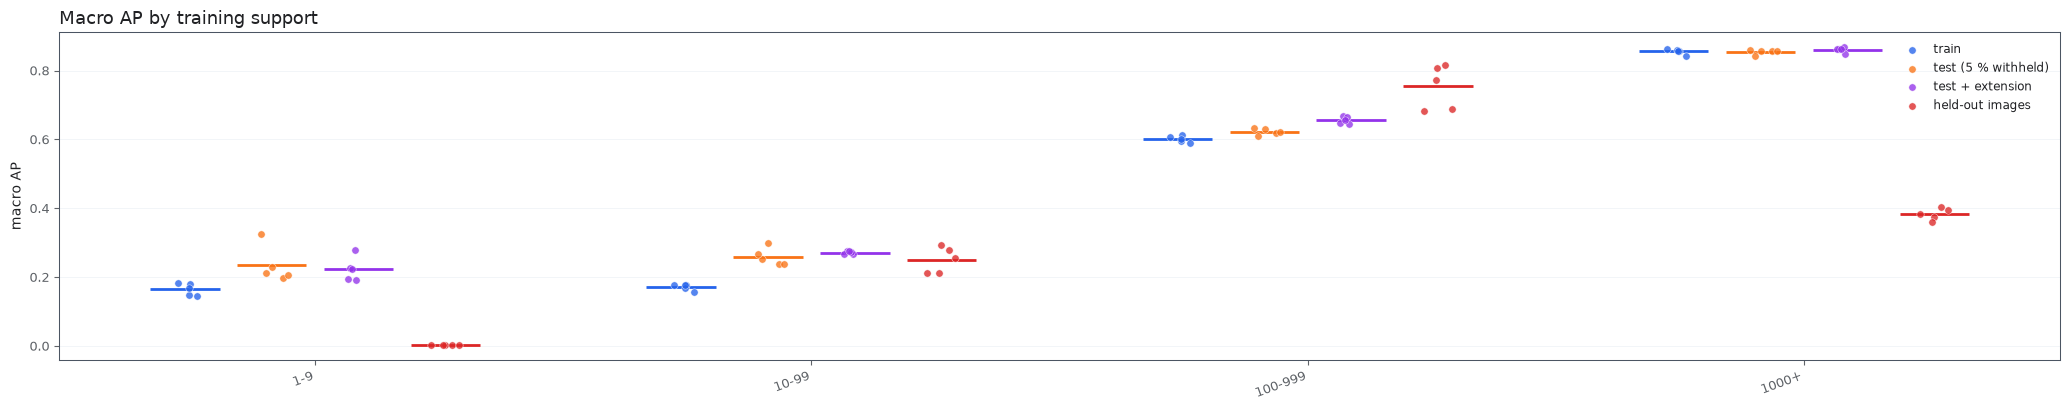

In [3]:
shown = strata[strata.grouping == 'train_support']
order = ['1-9', '10-99', '100-999', '1000+']
figures.repetition_points(shown, value='average_precision', group='stratum', hue='evaluation', order=order, hue_order=EVALUATIONS, colors=EVALUATION_COLORS, ylabel='macro AP', title='Macro AP by training support', theme=theme);
display(shown[shown.repetition == 0].pivot_table(index='stratum', columns='evaluation', values='eligible_classes')[[name for name in EVALUATIONS if name in set(shown.evaluation)]])
display(metric_columns_table(shown[shown.evaluation.isin(EVALUATIONS)], ['evaluation', 'stratum']))

### Remarks

- Same dependence on training support as on the narrow axis (0.22-0.27 below 100 positives, 0.86 above 1000).

### Notes

## Macro AP by frequency bucket

### Methodology

#### Theoretical

The macro AP within a stratum shows how prediction quality depends on the stratifying property.

#### Implementation

`strata_metrics` rows with grouping `frequency`, ranking population `annotation_retrieval`.

#### Figure descriptions

x = stratum, colour = evaluation population, one point per repetition, bar = mean. Tables: eligible classes, then the complete metric set per evaluation population and stratum (mean +/- SD over repetitions).

evaluation,train,test,test_combined,heldout_image
stratum,,,,
frequent,471.0,471.0,471.0,18.0
medium,74.0,73.0,74.0,1.0
rare,18.0,16.0,18.0,1.0


average_precision micro_average_precision            roc_auc micro_roc_auc ap_above_prevalence micro_prevalence          precision             recall                 f1  \
evaluation    stratum                                                                                                                                                                              
heldout_image frequent  0.4039 +/- 0.0169                     NaN  0.7086 +/- 0.0137           NaN   0.1611 +/- 0.0169              NaN  0.4002 +/- 0.0484  0.1322 +/- 0.0134  0.1418 +/- 0.0177   
              medium    0.2497 +/- 0.0378                     NaN   0.8851 +/- 0.018           NaN   0.1762 +/- 0.0378              NaN        0.0 +/- 0.0        0.0 +/- 0.0        0.0 +/- 0.0   
              rare      0.0019 +/- 0.0003                     NaN  0.8877 +/- 0.0138           NaN   0.0015 +/- 0.0003              NaN        0.0 +/- 0.0        0.0 +/- 0.0        0.0 +/- 0.0   
test          frequent   0.781 +/- 0.0075                     NaN  0.9897 +/- 0.0003           NaN    0.719 +/- 0.0075              NaN    0.67 +/- 0.0151  0.6005 +/- 0.0173   0.594 +/- 0.0177   
              medium     0.2588 +/- 0.025                     NaN  0.9917 +/- 0.0005           NaN    0.2582 +/- 0.025              NaN  0.0237 +/- 0.0096  0.1493 +/- 0.0294  0.0255 +/- 0.0062   
              rare      0.2345 +/- 0.0514                     NaN  0.9813 +/- 0.0049           NaN   0.2343 +/- 0.0514              NaN  0.0561 +/- 0.0285   0.225 +/- 0.1135  0.0618 +/- 0.0296   
test_combined frequent  0.7956 +/- 0.0077                     NaN  0.9895 +/- 0.0005           NaN   0.7278 +/- 0.0077              NaN  0.6911 +/- 0.0107   0.601 +/- 0.0165  0.6007 +/- 0.0173   
              medium    0.2713 +/- 0.0046                     NaN  0.9764 +/- 0.0005           NaN   0.2668 +/- 0.0046              NaN  0.0456 +/- 0.0072  0.1526 +/- 0.0401  0.0281 +/- 0.0046   
              rare       0.2231 +/- 0.035                     NaN  0.9692 +/- 0.0023           NaN    0.2197 +/- 0.035              NaN  0.1106 +/- 0.0279  0.1823 +/- 0.0619  0.0537 +/- 0.0191   
train         frequent  0.7747 +/- 0.0072                     NaN  0.9899 +/- 0.0003           NaN    0.713 +/- 0.0072              NaN  0.7012 +/- 0.0156   0.6025 +/- 0.017  0.5966 +/- 0.0168   
              medium    0.1715 +/- 0.0094                     NaN  0.9935 +/- 0.0005           NaN    0.171 +/- 0.0094              NaN  0.0405 +/- 0.0141    0.1524 +/- 0.04  0.0188 +/- 0.0036   
              rare      0.1646 +/- 0.0178                     NaN   0.994 +/- 0.0017           NaN   0.1646 +/- 0.0178              NaN  0.0389 +/- 0.0299  0.1864 +/- 0.0749   0.0297 +/- 0.018   

                       micro_precision micro_recall micro_f1 hamming_loss  
evaluation    stratum                                                      
heldout_image frequent             NaN          NaN      NaN          NaN  
              medium               NaN          NaN      NaN          NaN  
              rare                 NaN          NaN      NaN          NaN  
test          frequent             NaN          NaN      NaN          NaN  
              medium               NaN          NaN      NaN          NaN  
              rare                 NaN          NaN      NaN          NaN  
test_combined frequent             NaN          NaN      NaN          NaN  
              medium               NaN          NaN      NaN          NaN  
              rare                 NaN          NaN      NaN          NaN  
train         frequent             NaN          NaN      NaN          NaN  
              medium               NaN          NaN      NaN          NaN  
              rare                 NaN          NaN      NaN          NaN

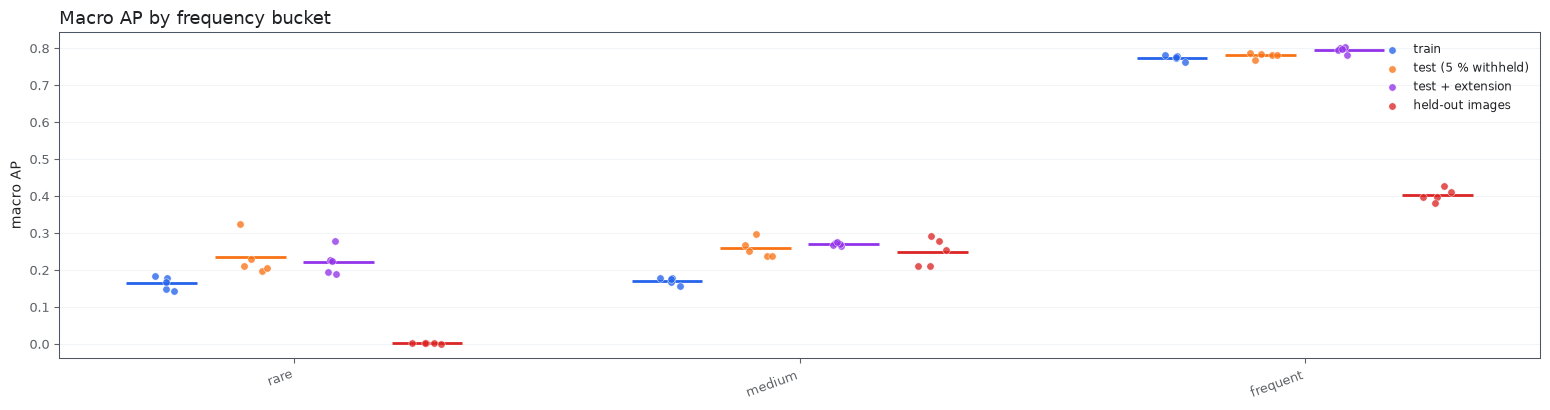

In [4]:
shown = strata[strata.grouping == 'frequency']
order = ['rare', 'medium', 'frequent']
figures.repetition_points(shown, value='average_precision', group='stratum', hue='evaluation', order=order, hue_order=EVALUATIONS, colors=EVALUATION_COLORS, ylabel='macro AP', title='Macro AP by frequency bucket', theme=theme);
display(shown[shown.repetition == 0].pivot_table(index='stratum', columns='evaluation', values='eligible_classes')[[name for name in EVALUATIONS if name in set(shown.evaluation)]])
display(metric_columns_table(shown[shown.evaluation.isin(EVALUATIONS)], ['evaluation', 'stratum']))

### Remarks

- Note: the frequency buckets carry only macro metrics (see the narrow-axis notebook); `train_support` carries the complete set.

### Notes

## Macro AP by class set

### Methodology

#### Theoretical

The macro AP within a stratum shows how prediction quality depends on the stratifying property.

#### Implementation

`strata_metrics` rows with grouping `class_set`, ranking population `annotation_retrieval`.

#### Figure descriptions

x = stratum, colour = evaluation population, one point per repetition, bar = mean. Tables: eligible classes, then the complete metric set per evaluation population and stratum (mean +/- SD over repetitions).

evaluation,train,test,test_combined,heldout_image
stratum,,,,
common,508.0,508.0,508.0,17.0
extension,55.0,52.0,55.0,3.0


average_precision micro_average_precision            roc_auc      micro_roc_auc ap_above_prevalence micro_prevalence          precision             recall  \
evaluation    stratum                                                                                                                                                                 
heldout_image common     0.3722 +/- 0.0143       0.5978 +/- 0.0183  0.7157 +/- 0.0121   0.8107 +/- 0.007   0.1382 +/- 0.0143   0.2339 +/- 0.0  0.3496 +/- 0.0418  0.1354 +/- 0.0093   
              extension  0.3981 +/- 0.0292       0.4153 +/- 0.0447  0.7869 +/- 0.0174  0.8107 +/- 0.0127   0.2422 +/- 0.0292   0.1559 +/- 0.0  0.4204 +/- 0.0874   0.026 +/- 0.0287   
test          common     0.6911 +/- 0.0084        0.8755 +/- 0.007  0.9895 +/- 0.0004   0.995 +/- 0.0002   0.6386 +/- 0.0084   0.0525 +/- 0.0  0.5606 +/- 0.0138  0.5203 +/- 0.0166   
              extension   0.7579 +/- 0.015       0.8956 +/- 0.0183  0.9916 +/- 0.0004  0.9962 +/- 0.0003    0.7088 +/- 0.015    0.049 +/- 0.0  0.6424 +/- 0.0146  0.6348 +/- 0.0078   
test_combined common     0.7048 +/- 0.0074       0.8661 +/- 0.0064  0.9869 +/- 0.0005  0.9933 +/- 0.0003   0.6463 +/- 0.0074   0.0585 +/- 0.0  0.5848 +/- 0.0098  0.5206 +/- 0.0178   
              extension  0.7411 +/- 0.0124       0.9028 +/- 0.0151  0.9896 +/- 0.0007  0.9961 +/- 0.0003   0.6933 +/- 0.0124   0.0479 +/- 0.0   0.614 +/- 0.0103  0.6032 +/- 0.0082   
train         common     0.6729 +/- 0.0069        0.8754 +/- 0.007  0.9905 +/- 0.0004   0.995 +/- 0.0002   0.6205 +/- 0.0069   0.0523 +/- 0.0   0.589 +/- 0.0141  0.5216 +/- 0.0189   
              extension   0.7045 +/- 0.016        0.896 +/- 0.0177  0.9913 +/- 0.0006  0.9964 +/- 0.0003    0.6581 +/- 0.016   0.0464 +/- 0.0  0.6318 +/- 0.0155    0.6077 +/- 0.01   

                                        f1    micro_precision       micro_recall           micro_f1       hamming_loss  
evaluation    stratum                                                                                                   
heldout_image common     0.1423 +/- 0.0118  0.6782 +/- 0.0276  0.2925 +/- 0.0261  0.4083 +/- 0.0281   0.198 +/- 0.0062  
              extension  0.0442 +/- 0.0461   0.6661 +/- 0.201  0.0346 +/- 0.0405  0.0615 +/- 0.0694  0.1544 +/- 0.0017  
test          common      0.4944 +/- 0.016  0.8344 +/- 0.0055  0.8657 +/- 0.0099  0.8497 +/- 0.0033  0.0161 +/- 0.0003  
              extension  0.6052 +/- 0.0078  0.8433 +/- 0.0064  0.9013 +/- 0.0068  0.8713 +/- 0.0012  0.0131 +/- 0.0002  
test_combined common     0.5005 +/- 0.0159  0.8279 +/- 0.0087  0.8172 +/- 0.0105  0.8225 +/- 0.0054  0.0206 +/- 0.0006  
              extension  0.5775 +/- 0.0102  0.8473 +/- 0.0067  0.8877 +/- 0.0051   0.867 +/- 0.0019   0.013 +/- 0.0003  
train         common     0.4942 +/- 0.0154  0.8342 +/- 0.0057  0.8671 +/- 0.0099  0.8503 +/- 0.0033   0.016 +/- 0.0003  
              extension  0.5793 +/- 0.0104  0.8463 +/- 0.0065   0.901 +/- 0.0067  0.8728 +/- 0.0012  0.0122 +/- 0.0002

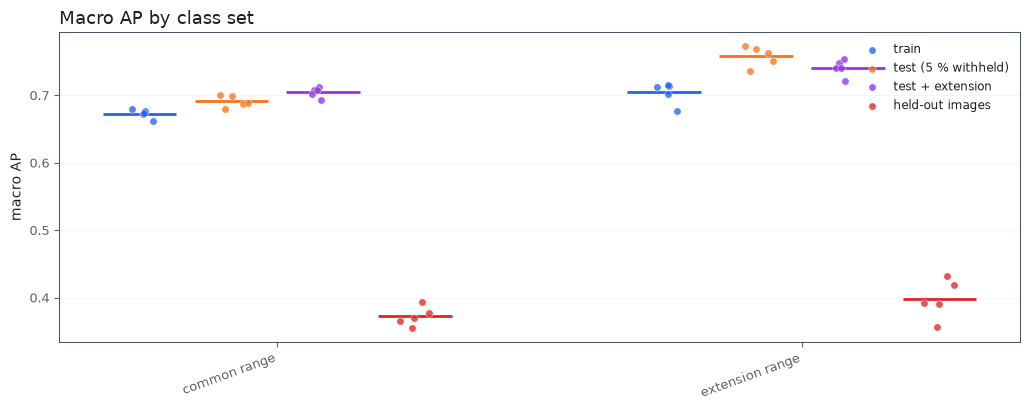

In [5]:
shown = strata[strata.grouping == 'class_set']
order = [value for value in figures.CLASS_SET_ORDER if value in set(strata.stratum)]
figures.repetition_points(shown, value='average_precision', group='stratum', hue='evaluation', order=order, hue_order=EVALUATIONS, colors=EVALUATION_COLORS, ylabel='macro AP', title='Macro AP by class set', theme=theme);
display(shown[shown.repetition == 0].pivot_table(index='stratum', columns='evaluation', values='eligible_classes')[[name for name in EVALUATIONS if name in set(shown.evaluation)]])
display(metric_columns_table(shown[shown.evaluation.isin(EVALUATIONS)], ['evaluation', 'stratum']))

### Remarks

- Extension classes reach a *higher* macro AP than common classes on test + extension (0.74 vs 0.71) and a similar one on held-out images (0.40 vs 0.37).

### Notes

## Macro AP by presence in held-out images

### Methodology

#### Theoretical

The macro AP within a stratum shows how prediction quality depends on the stratifying property.

#### Implementation

`strata_metrics` rows with grouping `heldout_presence`, ranking population `annotation_retrieval`.

#### Figure descriptions

x = stratum, colour = evaluation population, one point per repetition, bar = mean. Tables: eligible classes, then the complete metric set per evaluation population and stratum (mean +/- SD over repetitions).

/home/max/repositories/MSIAutoEncoderWrapper/src/msi_autoencoder_wrapper/visualization/pretraining.py:152: RuntimeWarning: Mean of empty slice
  ax.hlines(np.nanmean(values), x - width / 2.5, x + width / 2.5, color=colors[level], linewidth=2)


evaluation,train,test,test_combined,heldout_image
stratum,,,,
in_heldout,20.0,20.0,20.0,20.0
not_in_heldout,543.0,540.0,543.0,0.0


average_precision micro_average_precision            roc_auc      micro_roc_auc ap_above_prevalence micro_prevalence          precision             recall  \
evaluation    stratum                                                                                                                                                                      
heldout_image in_heldout      0.3761 +/- 0.0164       0.5809 +/- 0.0191  0.7264 +/- 0.0125  0.8129 +/- 0.0069   0.1538 +/- 0.0164   0.2222 +/- 0.0  0.3602 +/- 0.0436    0.119 +/- 0.012   
              not_in_heldout                NaN                     NaN                NaN                NaN                 NaN              NaN                NaN                NaN   
test          in_heldout       0.6712 +/- 0.024       0.8294 +/- 0.0229  0.9741 +/- 0.0018  0.9826 +/- 0.0019    0.5855 +/- 0.024   0.0857 +/- 0.0  0.5843 +/- 0.0535  0.3449 +/- 0.0117   
              not_in_heldout  0.6983 +/- 0.0084       0.8794 +/- 0.0076  0.9903 +/- 0.0004  0.9954 +/- 0.0002   0.6473 +/- 0.0084   0.0509 +/- 0.0  0.5676 +/- 0.0122  0.5378 +/- 0.0163   
test_combined in_heldout      0.6363 +/- 0.0205       0.8029 +/- 0.0276  0.9703 +/- 0.0026  0.9804 +/- 0.0024   0.5589 +/- 0.0205   0.0773 +/- 0.0  0.5869 +/- 0.0747  0.3309 +/- 0.0108   
              not_in_heldout   0.711 +/- 0.0075       0.8722 +/- 0.0065  0.9878 +/- 0.0005   0.994 +/- 0.0002   0.6543 +/- 0.0075   0.0567 +/- 0.0  0.5877 +/- 0.0086   0.536 +/- 0.0174   
train         in_heldout      0.6191 +/- 0.0207       0.8268 +/- 0.0233  0.9731 +/- 0.0023  0.9824 +/- 0.0021   0.5335 +/- 0.0207   0.0855 +/- 0.0  0.6058 +/- 0.0228  0.3445 +/- 0.0103   
              not_in_heldout   0.678 +/- 0.0072       0.8794 +/- 0.0076  0.9912 +/- 0.0003  0.9955 +/- 0.0002   0.6275 +/- 0.0072   0.0505 +/- 0.0  0.5927 +/- 0.0132  0.5368 +/- 0.0186   

                                             f1    micro_precision       micro_recall           micro_f1       hamming_loss  
evaluation    stratum                                                                                                        
heldout_image in_heldout       0.1276 +/- 0.016  0.6767 +/- 0.0274  0.2654 +/- 0.0273  0.3807 +/- 0.0298  0.1914 +/- 0.0054  
              not_in_heldout                NaN        0.0 +/- 0.0        0.0 +/- 0.0        0.0 +/- 0.0                NaN  
test          in_heldout      0.3585 +/- 0.0246  0.8397 +/- 0.0192  0.6632 +/- 0.0174   0.741 +/- 0.0164  0.0397 +/- 0.0025  
              not_in_heldout  0.5101 +/- 0.0153   0.835 +/- 0.0056  0.8816 +/- 0.0095  0.8576 +/- 0.0025  0.0149 +/- 0.0002  
test_combined in_heldout      0.3507 +/- 0.0211  0.8203 +/- 0.0201  0.6382 +/- 0.0177  0.7178 +/- 0.0168  0.0388 +/- 0.0023  
              not_in_heldout  0.5138 +/- 0.0155    0.83 +/- 0.0084  0.8322 +/- 0.0102   0.831 +/- 0.0046  0.0192 +/- 0.0005  
train         in_heldout      0.3577 +/- 0.0214  0.8365 +/- 0.0171  0.6606 +/- 0.0168  0.7381 +/- 0.0151  0.0401 +/- 0.0022  
              not_in_heldout  0.5079 +/- 0.0151  0.8352 +/- 0.0057  0.8831 +/- 0.0096  0.8584 +/- 0.0026  0.0147 +/- 0.0002

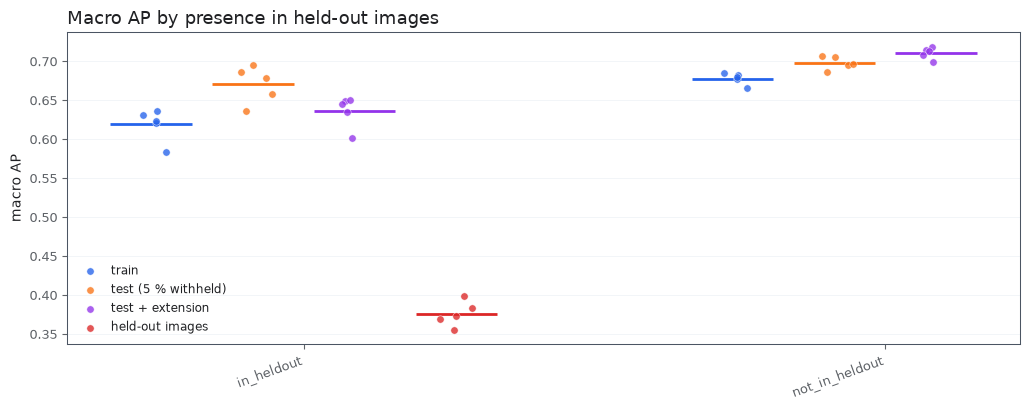

In [6]:
shown = strata[strata.grouping == 'heldout_presence']
order = ['in_heldout', 'not_in_heldout']
figures.repetition_points(shown, value='average_precision', group='stratum', hue='evaluation', order=order, hue_order=EVALUATIONS, colors=EVALUATION_COLORS, ylabel='macro AP', title='Macro AP by presence in held-out images', theme=theme);
display(shown[shown.repetition == 0].pivot_table(index='stratum', columns='evaluation', values='eligible_classes')[[name for name in EVALUATIONS if name in set(shown.evaluation)]])
display(metric_columns_table(shown[shown.evaluation.isin(EVALUATIONS)], ['evaluation', 'stratum']))

### Remarks

### Notes

## Class sets on every held-out image

### Methodology

#### Theoretical

The class-set strata evaluated per held-out image show whether an image-specific failure concerns the common
range, the boundary or the extension classes.

#### Implementation

`strata_metrics` rows with grouping `class_set` and group = held-out image, ranking population `annotation_retrieval`.

#### Figure descriptions

No figure; rows = image and class set, columns = metrics (mean +/- SD over repetitions).

In [7]:
images = all_strata[(all_strata.grouping == 'class_set') & (all_strata.group != 'all') & (all_strata.population == 'annotation_retrieval')]
display(metric_columns_table(images, ['group', 'stratum']))

average_precision micro_average_precision            roc_auc      micro_roc_auc ap_above_prevalence micro_prevalence          precision             recall  \
group                stratum                                                                                                                                                                 
2024-02-20_01h45m20s common     0.6411 +/- 0.0139       0.7426 +/- 0.0106  0.7522 +/- 0.0113  0.7515 +/- 0.0252   0.1905 +/- 0.0139   0.4506 +/- 0.0  0.5123 +/- 0.0697  0.1676 +/- 0.0241   
                     extension  0.7437 +/- 0.0352       0.4996 +/- 0.0706  0.8759 +/- 0.0083   0.763 +/- 0.0606   0.5678 +/- 0.0352   0.1759 +/- 0.0        0.5 +/- 0.0   0.0251 +/- 0.019   
2024-02-20_01h46m58s common     0.6086 +/- 0.0071        0.8284 +/- 0.011  0.7887 +/- 0.0189   0.887 +/- 0.0062   0.1632 +/- 0.0071   0.4455 +/- 0.0  0.4056 +/- 0.0402  0.1335 +/- 0.0139   
                     extension  0.7795 +/- 0.0063       0.8787 +/- 0.0435  0.8148 +/- 0.0064  0.8697 +/- 0.0295   0.2789 +/- 0.0063   0.5007 +/- 0.0  0.7998 +/- 0.2737  0.0326 +/- 0.0405   
2024-02-20_01h54m41s common      0.5278 +/- 0.004        0.8399 +/- 0.007  0.7375 +/- 0.0065   0.9069 +/- 0.004    0.1436 +/- 0.004   0.3842 +/- 0.0  0.4241 +/- 0.0472  0.1701 +/- 0.0042   
                     extension                NaN                     NaN                NaN                NaN                 NaN              NaN                NaN                NaN   

                                               f1    micro_precision       micro_recall           micro_f1       hamming_loss  
group                stratum                                                                                                   
2024-02-20_01h45m20s common     0.1882 +/- 0.0341  0.8685 +/- 0.0173  0.2927 +/- 0.0412  0.4364 +/- 0.0454  0.3388 +/- 0.0151  
                     extension  0.0467 +/- 0.0343        1.0 +/- 0.0  0.0221 +/- 0.0167  0.0427 +/- 0.0319   0.172 +/- 0.0029  
2024-02-20_01h46m58s common     0.1329 +/- 0.0092  0.8701 +/- 0.0319   0.2461 +/- 0.011  0.3836 +/- 0.0151  0.3522 +/- 0.0076  
                     extension  0.0588 +/- 0.0711  0.9997 +/- 0.0007  0.0395 +/- 0.0527  0.0721 +/- 0.0946  0.4809 +/- 0.0264  
2024-02-20_01h54m41s common     0.1987 +/- 0.0052   0.936 +/- 0.0122  0.3354 +/- 0.0296   0.4933 +/- 0.033  0.2641 +/- 0.0115  
                     extension                NaN        0.0 +/- 0.0        0.0 +/- 0.0        0.0 +/- 0.0                NaN

### Remarks

- Extension classes on held-out images: macro AP 0.74-0.78 in the two images that contain them (two classes each), but micro recall 0.02-0.04: they are ranked correctly and almost never exceed 0.5.
- Common classes: macro AP 0.53-0.64, micro recall 0.25-0.34.

### Notes

## Extension-range diagnostics

### Methodology

#### Theoretical

For every class and evaluation: the predicted-positive rate $\Pr(\hat Y \ge 0.5)$, the mean probability on
annotated positives and on all other entries, recall at 0.5 and the acquisition fraction of the class window.
A class set whose positives receive probabilities no higher than other entries is not learned; a set with
near-zero predicted-positive rate is predicted as absent everywhere.

#### Implementation

`extension_diagnostics` (one row per model, evaluation and class); repetition means are shown.

#### Figure descriptions

Table: medians over classes per class set and evaluation. Figure: x = mean probability on other entries, y =
mean probability on positives (repetition means, classes with at least one positive); diagonal = no
separation; colour = class set; left = test + extension, right = held-out images.

predicted_positive_rate  mean_probability_positive  mean_probability_other  recall_at_half  acquired_fraction
evaluation    class_set                                                                                                               
heldout_image common                      0.0000                     0.1447              6.9481e-06          0.0173                1.0
              extension                   0.0000                     0.1077              7.6230e-06          0.0267                1.0
test_combined common                      0.0293                     0.5389              6.3585e-03          0.5774                1.0
              extension                   0.0534                     0.8810              1.7217e-03          0.9496                1.0

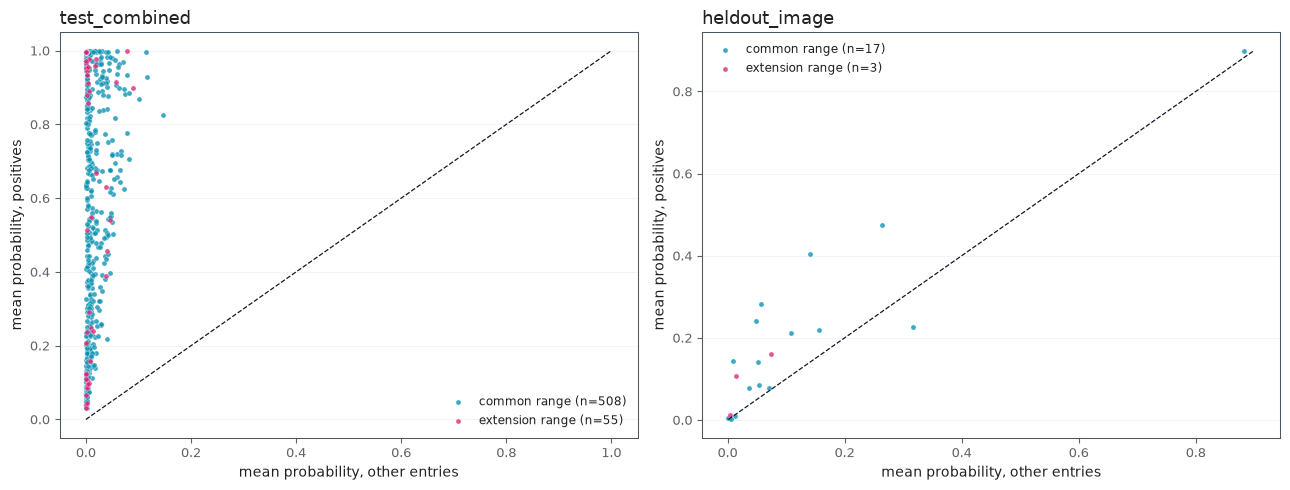

In [8]:
diagnostics = table('extension_diagnostics')
class_means = diagnostics.groupby(['evaluation', 'class_name', 'class_set'], as_index=False)[['positives', 'predicted_positive_rate', 'mean_probability_positive', 'mean_probability_other', 'recall_at_half', 'acquired_fraction']].mean()
display(class_means.groupby(['evaluation', 'class_set'])[['predicted_positive_rate', 'mean_probability_positive', 'mean_probability_other', 'recall_at_half', 'acquired_fraction']].median())
sets = [value for value in figures.CLASS_SET_ORDER if value in set(class_means.class_set)]
figure, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=theme.figure_dpi)
for ax, evaluation in zip(axes, ['test_combined', 'heldout_image']):
    shown = class_means[(class_means.evaluation == evaluation) & (class_means.positives > 0)]
    figures.paired_scatter(shown, x='mean_probability_other', y='mean_probability_positive', hue='class_set', hue_order=sets, xlabel='mean probability, other entries', ylabel='mean probability, positives', title=evaluation, ax=ax, theme=theme)
figure.tight_layout()

### Remarks

- Extension classes: median recall at 0.5 of 0.95 and mean positive probability 0.88 on test + extension (common: 0.58 / 0.54); on held-out images both sets collapse alike (predicted-positive rate 0.4-0.5 %).
- The class windows are acquired in every evaluated pixel (acquired fraction 1.0).

### Notes

## Probability quantiles by class set

### Methodology

#### Theoretical

Quantiles of $\hat Y$ on positives and on other entries per class set summarise the separation per set.

#### Implementation

`score_by_class_set`, repetition means.

#### Figure descriptions

No figure.

In [9]:
display(table('score_by_class_set').groupby(['evaluation', 'class_set', 'state'])[['q10', 'q25', 'q50', 'q75', 'q90']].mean())

q10         q25         q50         q75         q90
evaluation    class_set state                                                               
heldout_image common    other     0.0000e+00  2.3842e-08  2.8610e-07  3.2544e-06  6.4087e-05
                        positive  1.1353e-02  6.6595e-02  1.9924e-01  6.1741e-01  9.8281e-01
              extension other     0.0000e+00  3.5763e-08  4.0531e-07  6.9380e-06  5.2080e-04
                        positive  3.9607e-03  1.0437e-02  6.3733e-02  1.8806e-01  3.3016e-01
test_combined common    other     1.0581e-13  4.9454e-10  1.4841e-07  6.1612e-06  4.3000e-04
                        positive  2.6037e-01  6.5859e-01  9.4755e-01  9.9538e-01  9.9946e-01
              extension other     3.4507e-13  5.8372e-10  8.9385e-08  3.9789e-06  2.8367e-04
                        positive  4.2523e-01  9.2289e-01  9.8953e-01  9.9847e-01  9.9965e-01

### Remarks

### Notes

## Held-out annotations absent from the head

### Methodology

#### Theoretical

Annotations of the held-out images that were never observed in training cannot be predicted by construction.

#### Implementation

`unseen_heldout_classes`.

#### Figure descriptions

No figure.

In [10]:
display(table('unseen_heldout_classes'))

,ion_index,dataset_id,class_name,mz,in_axis,head_column,class_set
0,30,2024-02-20_01h54m41s,C49H93O12P|[M]-,904.641,True,-1,not_in_head


### Remarks

- One held-out annotation (C49H93O12P, 904.6 m/z, 01h54m41s) was never observed in training and cannot be predicted.

### Notes

## Results / Summary

### LLM

- **Observed:** extension classes are learned at least as well as common classes (macro AP 0.74 vs 0.71, recall 0.95 vs 0.58 on test + extension); on held-out images both sets collapse in the same way.
- **Observed:** the hypothesis that the wide model "predicts zeros" in the new range is not supported for prediction on seen images; on new images the head predicts almost nothing for every class set.
- **Interpretation:** the failure on new images is an image-level (domain) generalization failure of the head, independent of the m/z range.

### Person